# Olist Initial Purchase Logistic Regression

## Project Objective

This notebook develops a **Logistic Regression baseline model** to predict whether a customer will make a repeat purchase within 90 days of their initial purchase.

The model uses information available at the time of the customer's initial purchase. The goal is to evaluate whether initial-purchase customer and order characteristics contain enough information to meaningfully predict future purchasing behavior.

The modeling dataset was constructed in PostgreSQL and is loaded into Python for data preparation, modeling, and evaluation.

## Modeling Approach

This notebook will:

1. Load and inspect the initial-purchase modeling dataset.
2. Investigate missing values and define the final modeling population.
3. Define the target and model features.
4. Split the data chronologically into training and testing sets.
5. Preprocess numeric and categorical features.
6. Train a Logistic Regression baseline.
7. Evaluate the model using classification and ranking metrics.
8. Examine model coefficients and predicted probabilities.

### Notebook role

This is the **historical Original 8 Logistic Regression baseline**. It intentionally retains its complete-case preprocessing and single chronological test design so its corrected baseline can be compared with the other historical baselines. It is not the final enriched-model missing-data strategy; that design is documented in notebooks 104–105.

In [1]:
# Import data, preprocessing, baseline-model, and evaluation libraries.
import os
from getpass import getuser

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, auc, accuracy_score, precision_score,
    recall_score, f1_score, average_precision_score
)

In [2]:
# Create a SQLAlchemy connection to the PostgreSQL Olist project database.

# DATABASE_URL makes the notebooks portable without storing a password or machine-specific user name.
# If it is unset, use the documented local PostgreSQL convention for the active operating-system user.
database_url = os.getenv(
    "DATABASE_URL",
    f"postgresql+psycopg2://{getuser()}@localhost:5432/olist_project",
)
engine = create_engine(database_url)

In [3]:
# Confirm that the PostgreSQL connection is working.

with engine.connect() as connection:
    print("PostgreSQL connection successful")

PostgreSQL connection successful


In [4]:
# Read the corrected customer-level Original 8 source. Each row is one eligible customer; no data is written back to PostgreSQL.
# Load the modeling dataset created in PostgreSQL.

df = pd.read_sql(
    "SELECT * FROM customer_initial_purchase_model",
    engine
)

In [5]:
# Inspect the first few rows to verify that the data loaded correctly.

df.head()

,customer_unique_id,repeat_purchase_90d,customer_state,first_order_date,first_order_amount,product_amount,freight_amount,products_ordered,unique_products_ordered,number_of_categories,number_of_sellers,payment_installments,freight_to_order_ratio
0,0000366f3b9a7992bf8c76cfdf3221e2,No,SP,2018-05-10 10:56:27,141.90,129.90,12.00,1.0,1.0,1.0,1.0,8.0,0.084567
1,0000b849f77a49e4a4ce2b2a4ca5be3f,No,SP,2018-05-07 11:11:27,27.19,18.90,8.29,1.0,1.0,1.0,1.0,1.0,0.304892
2,0000f46a3911fa3c0805444483337064,No,SC,2017-03-10 21:05:03,86.22,69.00,17.22,1.0,1.0,1.0,1.0,8.0,0.199722
3,0000f6ccb0745a6a4b88665a16c9f078,No,PA,2017-10-12 20:29:41,43.62,25.99,17.63,1.0,1.0,1.0,1.0,4.0,0.404172
4,0004aac84e0df4da2b147fca70cf8255,No,SP,2017-11-14 19:45:42,196.89,180.00,16.89,1.0,1.0,1.0,1.0,6.0,0.085784


In [6]:
# Inspect the structure, row count, data types, and non-null counts.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86924 entries, 0 to 86923
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_unique_id       86924 non-null  object        
 1   repeat_purchase_90d      86924 non-null  object        
 2   customer_state           86924 non-null  object        
 3   first_order_date         86924 non-null  datetime64[ns]
 4   first_order_amount       86269 non-null  float64       
 5   product_amount           86269 non-null  float64       
 6   freight_amount           86269 non-null  float64       
 7   products_ordered         86269 non-null  float64       
 8   unique_products_ordered  86269 non-null  float64       
 9   number_of_categories     86269 non-null  float64       
 10  number_of_sellers        86269 non-null  float64       
 11  payment_installments     86923 non-null  float64       
 12  freight_to_order_ratio   86269 n

## Missing-Value Investigation

The corrected SQL dataset is inspected before modeling. The baseline preserves the existing complete-case approach so that all three refreshed baseline models use the same original eight predictors and the same customer population.

In [7]:
# Identify how many missing values are present in each column.

df.isna().sum()

customer_unique_id           0
repeat_purchase_90d          0
customer_state               0
first_order_date             0
first_order_amount         655
product_amount             655
freight_amount             655
products_ordered           655
unique_products_ordered    655
number_of_categories       655
number_of_sellers          655
payment_installments         1
freight_to_order_ratio     655
dtype: int64

In [8]:
# Retain complete-case filtering as a documented historical-baseline choice, not as the final enriched-model imputation strategy.
# Create the modeling dataset by excluding customers missing
# the first-order amount, which represents missing initial-purchase information.

df_model = df.dropna(subset=["first_order_amount"])

In [9]:
# Confirm the size of the modeling population after removing customers
# missing initial-purchase information.

df_model.shape

(86269, 13)

In [10]:
# Verify that missing initial-purchase information has been removed.

df_model.isna().sum()

customer_unique_id         0
repeat_purchase_90d        0
customer_state             0
first_order_date           0
first_order_amount         0
product_amount             0
freight_amount             0
products_ordered           0
unique_products_ordered    0
number_of_categories       0
number_of_sellers          0
payment_installments       1
freight_to_order_ratio     0
dtype: int64

In [11]:
# Inspect the one remaining customer with missing payment-installment information.

df_model[df_model["payment_installments"].isna()]

,customer_unique_id,repeat_purchase_90d,customer_state,first_order_date,first_order_amount,product_amount,freight_amount,products_ordered,unique_products_ordered,number_of_categories,number_of_sellers,payment_installments,freight_to_order_ratio
44595,830d5b7aaa3b6f1e9ad63703bec97d23,No,SP,2016-09-15 12:16:38,143.46,134.97,8.49,3.0,1.0,1.0,1.0,NaN,0.05918


In [12]:
# The final drop removes the remaining missing field so this historical baseline reproduces a true complete-case experiment.
# Create the final modeling dataset by excluding the one remaining
# customer with missing payment-installment information.

df_final = df_model.dropna()

In [13]:
# Confirm the final modeling population size.

df_final.shape

(86268, 13)

In [14]:
# Verify that the final modeling dataset contains no missing values.

df_final.isna().sum()

customer_unique_id         0
repeat_purchase_90d        0
customer_state             0
first_order_date           0
first_order_amount         0
product_amount             0
freight_amount             0
products_ordered           0
unique_products_ordered    0
number_of_categories       0
number_of_sellers          0
payment_installments       0
freight_to_order_ratio     0
dtype: int64

## Final Modeling Population

Customers with missing initial-event predictor information are excluded for this controlled baseline refresh. This preserves the original complete-case methodology; no imputation or missingness-feature strategy is introduced in this pass. The executed outputs below report the corrected population size.

## Feature and Target Preparation

The target variable is `repeat_purchase_90d`, indicating whether a customer made a repeat purchase within 90 days of their initial purchase.

The baseline model uses customer and initial-purchase characteristics that would have been available at the prediction point.

`customer_unique_id` is retained in the original dataset for customer identification but is excluded from the model features.

`first_order_date` is also excluded from the baseline model. It may be revisited later as a temporal feature.

The remaining variables are used as model features.

In [15]:
# Original 8 contains only information available at the initial-purchase event. product_amount and freight_amount remain in SQL for auditability but are omitted because they are deterministically redundant.
# Define the binary target variable:
# 0 = no repeat purchase within 90 days
# 1 = repeat purchase within 90 days

y = df_final["repeat_purchase_90d"].map({"No": 0, "Yes": 1})

# Define the model features available at the prediction point.
# Customer ID and first-order date are intentionally excluded.

X = df_final[
    [
        "customer_state",
        "first_order_amount",
        "products_ordered",
        "unique_products_ordered",
        "number_of_categories",
        "number_of_sellers",
        "payment_installments",
        "freight_to_order_ratio"
    ]
]

In [16]:
# Confirm the number of observations and model features.

X.shape, y.shape

((86268, 8), (86268,))

## Chronological Train-Test Split

Customers are split chronologically at the recalculated 80th-percentile initial-event timestamp. Earlier customers form training data and later customers form testing data, which better reflects future scoring than a random split.

In [17]:
# A chronological split evaluates customers who purchased later in time, which better reflects future generalization than a random split.
# Sort initial purchase dates and use the 80th percentile observation
# as the chronological cutoff between training and testing periods.

cutoff_date = (
    df_final["first_order_date"]
    .sort_values()
    .iloc[int(len(df_final) * 0.80)]
)

cutoff_date

Timestamp('2018-04-24 09:10:20')

In [18]:
# Create the chronological training and testing populations.

train = df_final[df_final["first_order_date"] <= cutoff_date].copy()
test = df_final[df_final["first_order_date"] > cutoff_date].copy()

In [19]:
# Confirm the number of observations in each split.

train.shape, test.shape

((69015, 13), (17253, 13))

In [20]:
# Confirm that the split is approximately 80% training and 20% testing.

len(train) / len(df_final), len(test) / len(df_final)

(0.8000069550702462, 0.19999304492975378)

In [21]:
# Define the training and testing features using the same feature set
# established above.

X_train = train[
    [
        "customer_state",
        "first_order_amount",
        "products_ordered",
        "unique_products_ordered",
        "number_of_categories",
        "number_of_sellers",
        "payment_installments",
        "freight_to_order_ratio"
    ]
]

y_train = train["repeat_purchase_90d"].map({"No": 0, "Yes": 1})

X_test = test[
    [
        "customer_state",
        "first_order_amount",
        "products_ordered",
        "unique_products_ordered",
        "number_of_categories",
        "number_of_sellers",
        "payment_installments",
        "freight_to_order_ratio"
    ]
]

y_test = test["repeat_purchase_90d"].map({"No": 0, "Yes": 1})

In [22]:
# Confirm the dimensions of the training and testing data.

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((69015, 8), (69015,), (17253, 8), (17253,))

In [23]:
# Report corrected class counts and prevalence in each chronological period.
for split_name, target in [("Training", y_train), ("Testing", y_test)]:
    print(f"{split_name} set:")
    print(target.value_counts().sort_index())
    print(f"Positive-class prevalence: {target.mean():.4%}\n")

Training set:
repeat_purchase_90d
0    67557
1     1458
Name: count, dtype: int64
Positive-class prevalence: 2.1126%

Testing set:
repeat_purchase_90d
0    17027
1      226
Name: count, dtype: int64
Positive-class prevalence: 1.3099%



## Data Preprocessing

The numeric features are standardized so that they are on comparable scales.

The categorical `customer_state` feature is one-hot encoded into separate binary variables.

The preprocessing transformations are **fit using only the training data** and then applied to both the training and testing data. This prevents information from the testing period from influencing the preprocessing step.

In [24]:
# Identify the categorical and numeric features.

categorical_features = ["customer_state"]

numeric_features = [
    "first_order_amount",
    "products_ordered",
    "unique_products_ordered",
    "number_of_categories",
    "number_of_sellers",
    "payment_installments",
    "freight_to_order_ratio"
]

In [25]:
# ColumnTransformer keeps numeric and categorical treatment explicit. StandardScaler uses training-set
# scale statistics so Logistic Regression compares effects on a common numeric scale; OneHotEncoder
# turns state labels into indicators and ignores a later unseen state rather than failing.
# Build the preprocessing transformer.
# Numeric features are standardized and customer_state is one-hot encoded.

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [26]:
# Fit the preprocessing steps using the training data only.

preprocessor.fit(X_train)

ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                 ['first_order_amount', 'products_ordered',
                                  'unique_products_ordered',
                                  'number_of_categories', 'number_of_sellers',
                                  'payment_installments',
                                  'freight_to_order_ratio']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['customer_state'])])

In [27]:
# Transform both training and testing data using the fitted preprocessor.

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [28]:
# Confirm that both datasets contain the same number of processed features.

X_train_processed.shape, X_test_processed.shape

((69015, 34), (17253, 34))

In [29]:
# Inspect the names of the processed features created by the transformer.

preprocessor.get_feature_names_out()

array(['numeric__first_order_amount', 'numeric__products_ordered',
       'numeric__unique_products_ordered',
       'numeric__number_of_categories', 'numeric__number_of_sellers',
       'numeric__payment_installments', 'numeric__freight_to_order_ratio',
       'categorical__customer_state_AC', 'categorical__customer_state_AL',
       'categorical__customer_state_AM', 'categorical__customer_state_AP',
       'categorical__customer_state_BA', 'categorical__customer_state_CE',
       'categorical__customer_state_DF', 'categorical__customer_state_ES',
       'categorical__customer_state_GO', 'categorical__customer_state_MA',
       'categorical__customer_state_MG', 'categorical__customer_state_MS',
       'categorical__customer_state_MT', 'categorical__customer_state_PA',
       'categorical__customer_state_PB', 'categorical__customer_state_PE',
       'categorical__customer_state_PI', 'categorical__customer_state_PR',
       'categorical__customer_state_RJ', 'categorical__customer_state_

## Logistic Regression Baseline

The preprocessed training data is used to fit a Logistic Regression model that predicts whether a customer will make a repeat purchase within 90 days of their initial purchase.

This model serves as a **baseline**. Its purpose is not to assume that Logistic Regression is the best possible model, but to establish a transparent reference point for later model comparisons.

In [30]:
# This untuned Logistic Regression is the historical linear baseline; max_iter only ensures convergence rather than selecting a model setting.
# Create the Logistic Regression baseline model.

model = LogisticRegression(max_iter=1000)

In [31]:
# Fit the Logistic Regression model using the training data.

model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000)

## Model Coefficients

The Logistic Regression coefficients show the direction and relative strength of each feature's relationship with the model's predicted likelihood of a repeat purchase.

Because the numeric features were standardized and the state variable was one-hot encoded, the coefficients can be compared more meaningfully than they could using the original feature scales.

In [32]:
# Match each model coefficient to its processed feature name.

feature_names = preprocessor.get_feature_names_out()

coefficients = pd.Series(
    model.coef_[0],
    index=feature_names
)

# Display coefficients from most negative to most positive.

coefficients.sort_values()

categorical__customer_state_CE     -0.626481
categorical__customer_state_MA     -0.504034
categorical__customer_state_SC     -0.386748
categorical__customer_state_PE     -0.371417
categorical__customer_state_AL     -0.331895
categorical__customer_state_PI     -0.328291
categorical__customer_state_GO     -0.291772
categorical__customer_state_BA     -0.186699
categorical__customer_state_TO     -0.181502
categorical__customer_state_PA     -0.170717
categorical__customer_state_AM     -0.169503
numeric__first_order_amount        -0.144036
categorical__customer_state_SE     -0.116857
categorical__customer_state_RN     -0.108916
categorical__customer_state_MG     -0.103015
categorical__customer_state_RR     -0.088045
categorical__customer_state_PB     -0.059748
categorical__customer_state_RS     -0.031642
categorical__customer_state_AP     -0.022408
categorical__customer_state_PR     -0.021315
numeric__number_of_sellers         -0.008598
categorical__customer_state_SP      0.017487
categorica

## Predictions on the Testing Set

The fitted model is now applied to the unseen testing period.

The first evaluation uses the model's default classification threshold of 0.50. Because repeat purchases are rare, it is important to inspect both the resulting class predictions and the underlying predicted probabilities.

In [33]:
# model.predict applies the default 0.50 probability threshold. With rare repeats, this thresholded result is secondary to ranking metrics.
# Generate class predictions for the unseen testing data.

y_test_pred = model.predict(X_test_processed)

In [34]:
# Count how many testing customers the model classified
# as non-repeat purchasers versus repeat purchasers.

pd.Series(y_test_pred).value_counts()

0    17253
Name: count, dtype: int64

In [35]:
# Evaluate the default 0.50 classification predictions
# against the actual testing outcomes.

print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, zero_division=0))

[[17027     0]
 [  226     0]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     17027
           1       0.00      0.00      0.00       226

    accuracy                           0.99     17253
   macro avg       0.49      0.50      0.50     17253
weighted avg       0.97      0.99      0.98     17253



### Default-threshold result

The 0.50 threshold is preserved only for baseline continuity. With a rare repeat-purchase outcome, accuracy can remain high even if few or no repeat purchasers are identified; the standardized train/test evaluation later reports the full threshold and ranking context.

In [36]:
# predict_proba supplies repeat-purchase probabilities for ROC-AUC and Average Precision, which evaluate ranking instead of a single threshold.
# Generate the model's predicted probability of a repeat purchase.
# The second column represents the probability of class 1.

y_test_proba = model.predict_proba(X_test_processed)[:, 1]

y_test_proba[:10]

array([0.02743842, 0.02140321, 0.01445797, 0.02280712, 0.02019464,
       0.01612372, 0.02645059, 0.03152102, 0.01781106, 0.0211656 ])

In [37]:
# Inspect the customers receiving the highest predicted probabilities
# of making a repeat purchase.

pd.Series(y_test_proba).sort_values(ascending=False).head(20)

6061     0.396219
518      0.281592
12810    0.246365
1819     0.168091
12108    0.159815
14751    0.147104
6384     0.140748
7310     0.135700
11163    0.132567
14213    0.129266
5225     0.129098
14414    0.122826
4566     0.119924
6585     0.115781
16170    0.110317
9164     0.106650
4187     0.102140
4990     0.101113
321      0.100072
4430     0.098284
dtype: float64

In [38]:
# Compare predicted probabilities with the actual repeat-purchase outcomes.

results = pd.DataFrame({
    "actual": y_test.values,
    "predicted_probability": y_test_proba
})

results.sort_values(
    "predicted_probability",
    ascending=False
).head(20)

,actual,predicted_probability
6061,0,0.396219
518,0,0.281592
12810,0,0.246365
1819,0,0.168091
12108,0,0.159815
14751,0,0.147104
6384,0,0.140748
7310,1,0.135700
11163,0,0.132567
14213,0,0.129266


## ROC-AUC

ROC-AUC measures probability ranking across thresholds. It is reported alongside Average Precision because the rare positive class makes accuracy alone misleading.

In [39]:
# Calculate ROC-AUC to evaluate how well the model ranks
# repeat purchasers above non-repeat purchasers.

roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.5098


## Precision-Recall Summaries

The existing trapezoidal precision-recall area is retained below only for continuity and is explicitly labeled as PR-AUC. The standardized evaluation section uses `average_precision_score` as the primary precision-recall summary.

In [40]:
# Calculate precision and recall across different probability thresholds.

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_proba
)

In [41]:
# Retain this curve-integral value for continuity; it is not Average Precision.
trapezoidal_pr_auc = auc(recall, precision)
print(f"Trapezoidal PR-AUC: {trapezoidal_pr_auc:.4f}")

Trapezoidal PR-AUC: 0.0158


### Precision-Recall interpretation

Average Precision in the standardized evaluation should be compared with the test positive-class prevalence. A result only slightly above prevalence indicates limited ability to prioritize repeat purchasers.

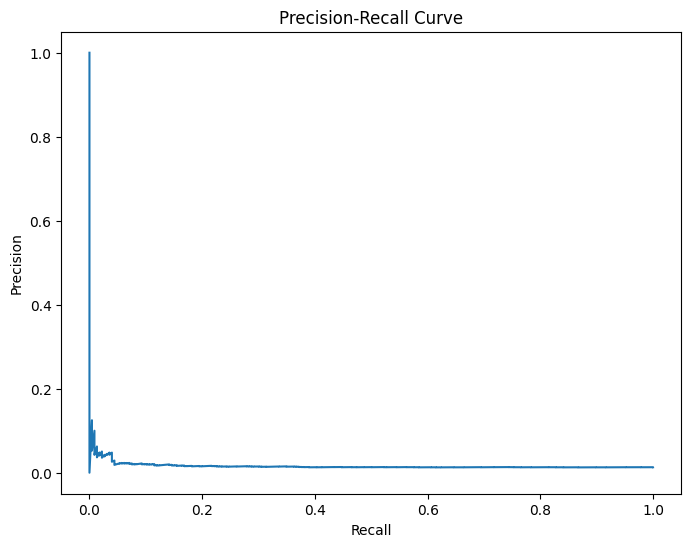

In [42]:
# Plot the precision-recall curve.

plt.figure(figsize=(8, 6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Baseline interpretation

Interpret the refreshed baseline using the executed standardized train/test metrics below. The fixed 0.50 threshold is not optimized in this notebook, and any high accuracy must be considered alongside the rare positive-class prevalence, Average Precision, and confusion matrices.

## Refreshed baseline summary

This controlled refresh preserves the original eight initial-purchase predictors, chronological split method, preprocessing, model configuration, and 0.50 threshold. It replaces historical outputs with results from the corrected complete initial-event dataset and adds consistent train-versus-test diagnostics.

## Standardized Baseline Evaluation

Each baseline reports the same train and chronological-test metrics at the unchanged 0.50 threshold. Accuracy is included for completeness but can be misleading for this rare outcome. ROC-AUC evaluates ranking across thresholds, while Average Precision summarizes precision-recall ranking relative to the positive-class prevalence.

In [43]:
# Accuracy can be high when nearly every customer is a non-repeater. Average Precision is interpreted
# against prevalence, while ROC-AUC measures ordering of positives above negatives. Training metrics are
# diagnostic; the later chronological test metrics assess generalization.
# Evaluate training and test predictions identically so generalization gaps are directly comparable.
def evaluate_baseline(y_true, predictions, probabilities):
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "positive_predictions": int(predictions.sum()),
        "actual_positives": int(y_true.sum()),
        "positive_prevalence": float(y_true.mean()),
    }

y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)
y_train_proba = model.predict_proba(X_train_processed)[:, 1]
y_test_proba = model.predict_proba(X_test_processed)[:, 1]

train_metrics = evaluate_baseline(y_train, y_train_pred, y_train_proba)
test_metrics = evaluate_baseline(y_test, y_test_pred, y_test_proba)
metrics_table = pd.DataFrame([train_metrics, test_metrics], index=["Training", "Testing"])
display(metrics_table)

print("Training confusion matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\nTesting confusion matrix:\n", confusion_matrix(y_test, y_test_pred))
print(f"\nROC-AUC train-test gap: {train_metrics['roc_auc'] - test_metrics['roc_auc']:.4f}")
print(f"Average Precision train-test gap: {train_metrics['average_precision'] - test_metrics['average_precision']:.4f}")
print(
    "Average Precision should be interpreted against the positive-class prevalence: "
    f"train {train_metrics['positive_prevalence']:.4%}, "
    f"test {test_metrics['positive_prevalence']:.4%}."
)

,accuracy,precision,recall,f1,roc_auc,average_precision,positive_predictions,actual_positives,positive_prevalence
Training,0.978874,0.0,0.0,0.0,0.590285,0.032222,0,1458,0.021126
Testing,0.986901,0.0,0.0,0.0,0.509800,0.016466,0,226,0.013099


Training confusion matrix:
 [[67557     0]
 [ 1458     0]]

Testing confusion matrix:
 [[17027     0]
 [  226     0]]

ROC-AUC train-test gap: 0.0805
Average Precision train-test gap: 0.0158
Average Precision should be interpreted against the positive-class prevalence: train 2.1126%, test 1.3099%.


### Interpreting train-test gaps

A weak train and test ranking result suggests limited usable signal in this eight-feature initial-purchase representation. A much stronger training result than chronological test result indicates that the fitted model learned historical patterns that did not generalize. A gap should be interpreted alongside the absolute test metrics and any change in positive-class prevalence over time.